# Backtest BTC 5 min sur Polymarket

Ce notebook joint les prévisions Oracle T-120 aux VWAP d'exécutions Polymarket par `market_id`, puis compare plusieurs règles de décision sur les issues résolues. Il calcule les métriques de classification, le P/L hypothétique, les exclusions, les résultats journaliers et la courbe de capital.

Les stratégies incluses sont : 
- Oracle sans filtre
- Oracle avec edge minimal configurable
- Oracle avec exclusion de la bande d'incertitude
- signal naïf `price_up >= 0.5`
- signal naïf avec exclusion de la bande d'incertitude 

Les données sont chargées depuis `data/backtesting/` du projet; les chemins relatifs de la cellule de configuration sont résolus depuis la racine du projet.

In [21]:
from __future__ import annotations

import csv
import json
import math
import statistics
from collections import Counter, defaultdict
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Parametres modifiables (chemins relatifs = relatifs a la racine du projet)
BACKTEST_CSV = "data/backtesting/backtest_oracle.csv"
PRICE_JSON = "data/backtesting/market_prices_t120.json"
STAKE_USD = 1.0
MIN_EDGE = 0.01  # edge strictement superieur a 1 point de probabilite
UNCERTAINTY_BAND = (0.45, 0.55)  # bornes inclusives
FEE_RATE = 0.0  # proportionnelle au montant investi; 0 = sans frais
SLIPPAGE_RATE = 0.0  # majoration du prix d'entree; 0 = sans slippage


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError("Impossible de trouver pyproject.toml depuis le dossier courant")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())


def resolve_input(configured: str | Path) -> Path:
    path = Path(configured).expanduser()
    if not path.is_absolute():
        path = PROJECT_ROOT / path
    path = path.resolve()
    if not path.is_file():
        raise FileNotFoundError(f"Fichier introuvable: {path}")
    return path


BACKTEST_PATH = resolve_input(BACKTEST_CSV)
PRICE_PATH = resolve_input(PRICE_JSON)

print(f"Python: {__import__('sys').version.split()[0]}")
print(f"pandas: {pd.__version__} | matplotlib: {plt.matplotlib.__version__}")
print(f"Projet: {PROJECT_ROOT}")
print(f"Backtest labels: {BACKTEST_PATH}")
print(f"VWAP executions: {PRICE_PATH}")
print(f"Stake: ${STAKE_USD:.2f} | edge min: > {MIN_EDGE:.1%} | bande: {UNCERTAINTY_BAND}")

Python: 3.12.13
pandas: 3.0.6 | matplotlib: 3.11.2
Projet: /Users/mac-JMELLO02/arbitrage_poly/arbitrage_poly
Backtest labels: /Users/mac-JMELLO02/arbitrage_poly/arbitrage_poly/data/backtesting/backtest_oracle.csv
VWAP executions: /Users/mac-JMELLO02/arbitrage_poly/arbitrage_poly/data/backtesting/market_prices_t120.json
Stake: $1.00 | edge min: > 1.0% | bande: (0.45, 0.55)


## Charger et valider les donnees

Le backtest Oracle fournit les probabilites, les cutoffs et les issues; le rapport JSON fournit les VWAP UP/DOWN des executions dans la fenetre de 15 secondes se terminant a T-120. La jointure est stricte : doublons, identifiants manquants ou cutoffs differents interrompent le notebook.

In [12]:
oracle = pd.read_csv(BACKTEST_PATH, dtype={"market_id": "string"})
price_document = json.loads(PRICE_PATH.read_text(encoding="utf-8"))
price_rows = price_document["markets"] if isinstance(price_document, dict) else price_document
prices = pd.DataFrame(price_rows)
prices["market_id"] = prices["market_id"].astype("string")
if "slug" in prices.columns:
    prices = prices.drop(columns="slug")

required_oracle = {
    "market_id", "slug", "prediction_cutoff_utc", "prob_up", "prob_down",
    "outcome_polymarket", "scored",
}
required_prices = {"market_id", "cutoff_utc", "price_up", "price_down"}
assert required_oracle.issubset(oracle.columns), f"Colonnes Oracle absentes: {required_oracle - set(oracle.columns)}"
assert required_prices.issubset(prices.columns), f"Colonnes prix absentes: {required_prices - set(prices.columns)}"
assert oracle["market_id"].notna().all() and prices["market_id"].notna().all()
assert oracle["market_id"].is_unique, "market_id duplique dans le CSV Oracle"
assert prices["market_id"].is_unique, "market_id duplique dans le rapport VWAP"

oracle_ids = set(oracle["market_id"].astype(str))
price_ids = set(prices["market_id"].astype(str))
assert oracle_ids == price_ids, (
    f"Jointure non exacte: seulement Oracle={len(oracle_ids-price_ids)}, "
    f"seulement prix={len(price_ids-oracle_ids)}"
)

backtest = oracle.merge(prices, on="market_id", how="inner", validate="one_to_one")
backtest["prediction_cutoff"] = pd.to_datetime(backtest["prediction_cutoff_utc"], utc=True, errors="raise")
backtest["price_cutoff"] = pd.to_datetime(backtest["cutoff_utc"], utc=True, errors="raise")
assert (backtest["prediction_cutoff"] == backtest["price_cutoff"]).all(), "Cutoff T-120 different entre les sources"

for column in ("prob_up", "prob_down", "price_up", "price_down"):
    backtest[column] = pd.to_numeric(backtest[column], errors="coerce")
backtest["outcome"] = backtest["outcome_polymarket"].astype("string").str.upper().str.strip()
backtest["is_scored"] = backtest["scored"].astype("string").str.lower().isin(["true", "1"])
backtest["date_utc"] = backtest["prediction_cutoff"].dt.strftime("%Y-%m-%d")

assert backtest["outcome"].isin(["UP", "DOWN"]).all(), "Issue resolue absente ou invalide"
assert backtest["prob_up"].dropna().between(0, 1).all(), "prob_up hors [0,1]"
assert backtest["price_up"].dropna().between(0, 1).all(), "price_up hors [0,1]"
assert backtest["price_down"].dropna().between(0, 1).all(), "price_down hors [0,1]"

print(f"Marches joints: {len(backtest):,} | identifiants uniques: {backtest.market_id.nunique():,}")
print(f"Cutoffs UTC: {backtest.prediction_cutoff.min()} -> {backtest.prediction_cutoff.max()}")
print(f"Scorables Oracle: {int(backtest.is_scored.sum()):,} | non scorables: {int((~backtest.is_scored).sum()):,}")
print(f"Fenetre VWAP: {price_document.get('price_window_seconds', 'inconnue')}")
display(backtest[["market_id", "slug", "prediction_cutoff", "prob_up", "price_up", "price_down", "outcome", "is_scored"]].head())

Marches joints: 2,880 | identifiants uniques: 2,880
Cutoffs UTC: 2026-09-13 13:14:00+00:00 -> 2026-09-23 13:09:00+00:00
Scorables Oracle: 2,722 | non scorables: 158
Fenetre VWAP: 15


,market_id,slug,prediction_cutoff,prob_up,price_up,price_down,outcome,is_scored
0,4495526,btc-updown-5m-1789305000,2026-09-13 13:14:00+00:00,0.999,0.989993,0.01262,UP,True
1,4495566,btc-updown-5m-1789305300,2026-09-13 13:19:00+00:00,0.001,NaN,0.99000,DOWN,True
2,4495587,btc-updown-5m-1789305600,2026-09-13 13:24:00+00:00,0.001,0.001000,0.99900,DOWN,True
3,4495596,btc-updown-5m-1789305900,2026-09-13 13:29:00+00:00,0.001,NaN,0.99000,DOWN,True
4,4495611,btc-updown-5m-1789306200,2026-09-13 13:34:00+00:00,0.999,NaN,0.01000,UP,True


## Couverture et qualite des predictions

Les metriques Oracle sont calculees sur les lignes marquees `scored`. Les exclusions de prix sont suivies separement : un marche resolu mais sans VWAP positive sur le cote choisi ne peut pas contribuer au P/L.

In [13]:
coverage = pd.DataFrame(
    [
        ("Marches resolus", len(backtest)),
        ("Scorables Oracle", int(backtest["is_scored"].sum())),
        ("Non scorables Oracle", int((~backtest["is_scored"]).sum())),
        ("VWAP UP disponible", int(backtest["price_up"].gt(0).sum())),
        ("VWAP DOWN disponible", int(backtest["price_down"].gt(0).sum())),
        ("Les deux VWAP disponibles", int((backtest["price_up"].gt(0) & backtest["price_down"].gt(0)).sum())),
    ],
    columns=["Controle", "Nombre"],
)
display(coverage)
print("Issues resolues:")
display(backtest["outcome"].value_counts().rename_axis("Issue").to_frame("Marches"))

oracle_rows = backtest.loc[
    backtest["is_scored"] & backtest["prob_up"].notna() & backtest["outcome"].isin(["UP", "DOWN"])
].copy()
y_up = oracle_rows["outcome"].eq("UP").astype(float)
p_up = oracle_rows["prob_up"].astype(float).clip(1e-15, 1 - 1e-15)
log_losses = [-(y * math.log(p) + (1 - y) * math.log(1 - p)) for y, p in zip(y_up, p_up)]
oracle_classification = {
    "marches_scores": len(oracle_rows),
    "accuracy_seuil_0.5": float(((p_up >= 0.5) == y_up.astype(bool)).mean()),
    "brier": float(((p_up - y_up) ** 2).mean()),
    "log_loss": float(statistics.mean(log_losses)),
}
display(pd.DataFrame([oracle_classification]).style.format({
    "accuracy_seuil_0.5": "{:.2%}", "brier": "{:.5f}", "log_loss": "{:.5f}"
}))

,Controle,Nombre
0,Marches resolus,2880
1,Scorables Oracle,2722
2,Non scorables Oracle,158
3,VWAP UP disponible,2557
4,VWAP DOWN disponible,2530
5,Les deux VWAP disponibles,2383


Issues resolues:


,Marches
Issue,
UP,1462
DOWN,1418


,marches_scores,accuracy_seuil_0.5,brier,log_loss
0,2722,88.72%,0.08874,0.34560


## Simuler les strategies

Une mise fixe achete `mise / prix_entree` parts. Au reglement, chaque part correcte vaut 1 USD; un pari perdant vaut zero. Le slippage est modelise en majorant le prix d'entree; les frais sont ajoutes au cout de la mise. Le filtre d'edge Oracle exige `fair_value_du_cote - VWAP_du_cote > MIN_EDGE`. La bande Oracle porte sur la fair value selectionnee; pour le signal naif, elle porte sur `price_up`.

In [22]:
def simulate_strategy(
    name: str,
    mode: str,
    *,
    min_edge: float | None = None,
    exclude_band: bool = False,
) -> tuple[dict, pd.DataFrame]:
    if mode not in {"oracle", "naive"}:
        raise ValueError("mode doit etre 'oracle' ou 'naive'")
    exclusions = Counter()
    trades = []

    for row in backtest.itertuples(index=False):
        if row.outcome not in {"UP", "DOWN"}:
            exclusions["issue_invalide"] += 1
            continue
        price_up = getattr(row, "price_up")
        price_down = getattr(row, "price_down")

        if mode == "oracle":
            if not row.is_scored or pd.isna(row.prob_up) or not 0 <= row.prob_up <= 1:
                exclusions["oracle_non_score"] += 1
                continue
            side = "UP" if row.prob_up >= 0.5 else "DOWN"
            fair_value = float(row.prob_up if side == "UP" else 1 - row.prob_up)
        else:
            if pd.isna(price_up) or not 0 <= price_up <= 1:
                exclusions["price_up_signal_invalide"] += 1
                continue
            side = "UP" if price_up >= 0.5 else "DOWN"
            fair_value = None

        if exclude_band:
            band_value = fair_value if mode == "oracle" else float(price_up)
            if UNCERTAINTY_BAND[0] <= band_value <= UNCERTAINTY_BAND[1]:
                exclusions["bande_incertitude"] += 1
                continue

        entry_vwap = price_up if side == "UP" else price_down
        if pd.isna(entry_vwap) or not 0 < entry_vwap <= 1:
            exclusions["vwap_entree_absente_ou_invalide"] += 1
            continue
        entry_price = float(entry_vwap) * (1 + SLIPPAGE_RATE)
        if not 0 < entry_price <= 1:
            exclusions["prix_apres_slippage_invalide"] += 1
            continue

        edge = fair_value - float(entry_vwap) if mode == "oracle" else None
        if min_edge is not None:
            if edge is None or edge <= min_edge:
                exclusions["edge_insuffisant"] += 1
                continue

        won = side == row.outcome
        shares = STAKE_USD / entry_price
        payout = shares if won else 0.0
        fee = STAKE_USD * FEE_RATE
        pnl = payout - STAKE_USD - fee
        trades.append({
            "strategy": name,
            "market_id": str(row.market_id),
            "cutoff": row.prediction_cutoff,
            "date_utc": row.date_utc,
            "side": side,
            "fair_value_side": fair_value,
            "price_up": float(price_up) if not pd.isna(price_up) else math.nan,
            "entry_vwap": float(entry_vwap),
            "entry_price_after_slippage": entry_price,
            "estimated_edge": edge,
            "outcome": row.outcome,
            "won": won,
            "shares": shares,
            "stake_usd": STAKE_USD,
            "fee_usd": fee,
            "payout_usd": payout,
            "pnl_usd": pnl,
        })

    detail = pd.DataFrame(trades)
    if detail.empty:
        summary = {"strategie": name, "paris": 0, "exclusions": dict(exclusions)}
        return summary, detail

    detail = detail.sort_values(["cutoff", "market_id"]).reset_index(drop=True)
    detail["cumulative_pnl_usd"] = detail["pnl_usd"].cumsum()
    detail["equity_usd"] = detail["cumulative_pnl_usd"]
    detail["running_peak_usd"] = detail["equity_usd"].cummax().clip(lower=0)
    detail["drawdown_usd"] = detail["equity_usd"] - detail["running_peak_usd"]
    wins = int(detail["won"].sum())
    total_stake = float(detail["stake_usd"].sum())
    total_payout = float(detail["payout_usd"].sum())
    total_fees = float(detail["fee_usd"].sum())
    total_pnl = float(detail["pnl_usd"].sum())
    edges = detail["estimated_edge"].dropna()
    summary = {
        "strategie": name,
        "paris": len(detail),
        "UP": int(detail["side"].eq("UP").sum()),
        "DOWN": int(detail["side"].eq("DOWN").sum()),
        "gains": wins,
        "pertes": len(detail) - wins,
        "taux_reussite": wins / len(detail),
        "mise_usd": total_stake,
        "frais_usd": total_fees,
        "payout_usd": total_payout,
        "pnl_net_usd": total_pnl,
        "ROI_sur_mises": total_pnl / total_stake if total_stake else math.nan,
        "entree_moyenne": float(detail["entry_vwap"].mean()),
        "entree_mediane": float(detail["entry_vwap"].median()),
        "edge_moyen": float(edges.mean()) if len(edges) else math.nan,
        "drawdown_max_usd": float(detail["drawdown_usd"].min()),
        "exclusions": dict(exclusions),
    }
    return summary, detail


strategy_definitions = [
    ("Oracle sans filtre", "oracle", None, False),
    (f"Oracle edge > {MIN_EDGE:.0%}", "oracle", MIN_EDGE, False),
    (f"Oracle edge > {MIN_EDGE:.0%} + bande exclue", "oracle", MIN_EDGE, True),
    ("Naif price_up >= 0.50", "naive", None, False),
    ("Naif bande [0.45, 0.55] exclue", "naive", None, True),
]

summaries = []
trade_details = {}
for name, mode, min_edge, exclude_band in strategy_definitions:
    summary, detail = simulate_strategy(
        name, mode, min_edge=min_edge, exclude_band=exclude_band
    )
    summaries.append(summary)
    trade_details[name] = detail
    print(name, ":", summary.get("paris", 0), "paris | exclusions:", summary["exclusions"])

summary_df = pd.DataFrame(summaries)
display(summary_df.drop(columns="exclusions").style.format({
    "taux_reussite": "{:.2%}", "ROI_sur_mises": "{:.2%}",
    "entree_moyenne": "{:.4f}", "entree_mediane": "{:.4f}",
    "edge_moyen": "{:.2%}", "mise_usd": "${:,.2f}",
    "frais_usd": "${:,.2f}", "payout_usd": "${:,.2f}",
    "pnl_net_usd": "${:+,.2f}", "drawdown_max_usd": "${:,.2f}",
}))

Oracle sans filtre : 2475 paris | exclusions: {'vwap_entree_absente_ou_invalide': 247, 'oracle_non_score': 158}
Oracle edge > 1% : 1090 paris | exclusions: {'edge_insuffisant': 1385, 'vwap_entree_absente_ou_invalide': 247, 'oracle_non_score': 158}
Oracle edge > 1% + bande exclue : 1050 paris | exclusions: {'edge_insuffisant': 1338, 'vwap_entree_absente_ou_invalide': 244, 'bande_incertitude': 90, 'oracle_non_score': 158}
Naif price_up >= 0.50 : 2512 paris | exclusions: {'price_up_signal_invalide': 323, 'vwap_entree_absente_ou_invalide': 45}
Naif bande [0.45, 0.55] exclue : 2432 paris | exclusions: {'price_up_signal_invalide': 323, 'bande_incertitude': 80, 'vwap_entree_absente_ou_invalide': 45}


,strategie,paris,UP,DOWN,gains,pertes,taux_reussite,mise_usd,frais_usd,payout_usd,pnl_net_usd,ROI_sur_mises,entree_moyenne,entree_mediane,edge_moyen,drawdown_max_usd
0,Oracle sans filtre,2475,1265,1210,2179,296,88.04%,"$2,475.00",$0.00,"$2,563.54",$+88.54,3.58%,0.8598,0.9710,4.98%,$-14.58
1,Oracle edge > 1%,1090,561,529,840,250,77.06%,"$1,090.00",$0.00,"$1,158.55",$+68.55,6.29%,0.7382,0.8422,17.15%,$-13.34
2,Oracle edge > 1% + bande exclue,1050,543,507,827,223,78.76%,"$1,050.00",$0.00,"$1,122.22",$+72.22,6.88%,0.7546,0.8560,17.00%,$-11.37
3,Naif price_up >= 0.50,2512,1337,1175,2272,240,90.45%,"$2,512.00",$0.00,"$2,545.00",$+33.00,1.31%,0.8924,0.9652,nan%,$-18.19
4,"Naif bande [0.45, 0.55] exclue",2432,1301,1131,2231,201,91.74%,"$2,432.00",$0.00,"$2,467.76",$+35.76,1.47%,0.9042,0.9688,nan%,$-11.97


## Resultats journaliers et courbes de capital

Le drawdown est mesure depuis le sommet precedent de la P/L cumulee, en ordre de cutoff UTC. L'echelle commence a zero : il s'agit de P/L cumulee et non d'un capital initial fourni par une strategie de taille variable.

strategie,"Naif bande [0.45, 0.55] exclue",Naif price_up >= 0.50,Oracle edge > 1%,Oracle edge > 1% + bande exclue,Oracle sans filtre
date_utc,,,,,
2026-09-13,$+0.95,$+0.79,$-3.78,$-4.27,$-2.45
2026-09-14,$+5.37,$+6.20,$+34.51,$+32.38,$+39.78
2026-09-15,$+4.50,$+3.26,$+0.45,$+1.45,$+0.02
2026-09-16,$+13.76,$+14.32,$+3.52,$+1.23,$+9.22
2026-09-17,$+1.08,$-0.12,$-1.86,$+2.14,$-3.00
2026-09-18,$+4.08,$+3.60,$+5.22,$+8.22,$+8.90
2026-09-19,$-5.21,$-7.54,$+2.78,$+4.78,$+2.28
2026-09-20,$+1.08,$-3.40,$+0.96,$+0.35,$-2.68
2026-09-21,$+0.14,$-0.71,$+17.96,$+14.57,$+22.80


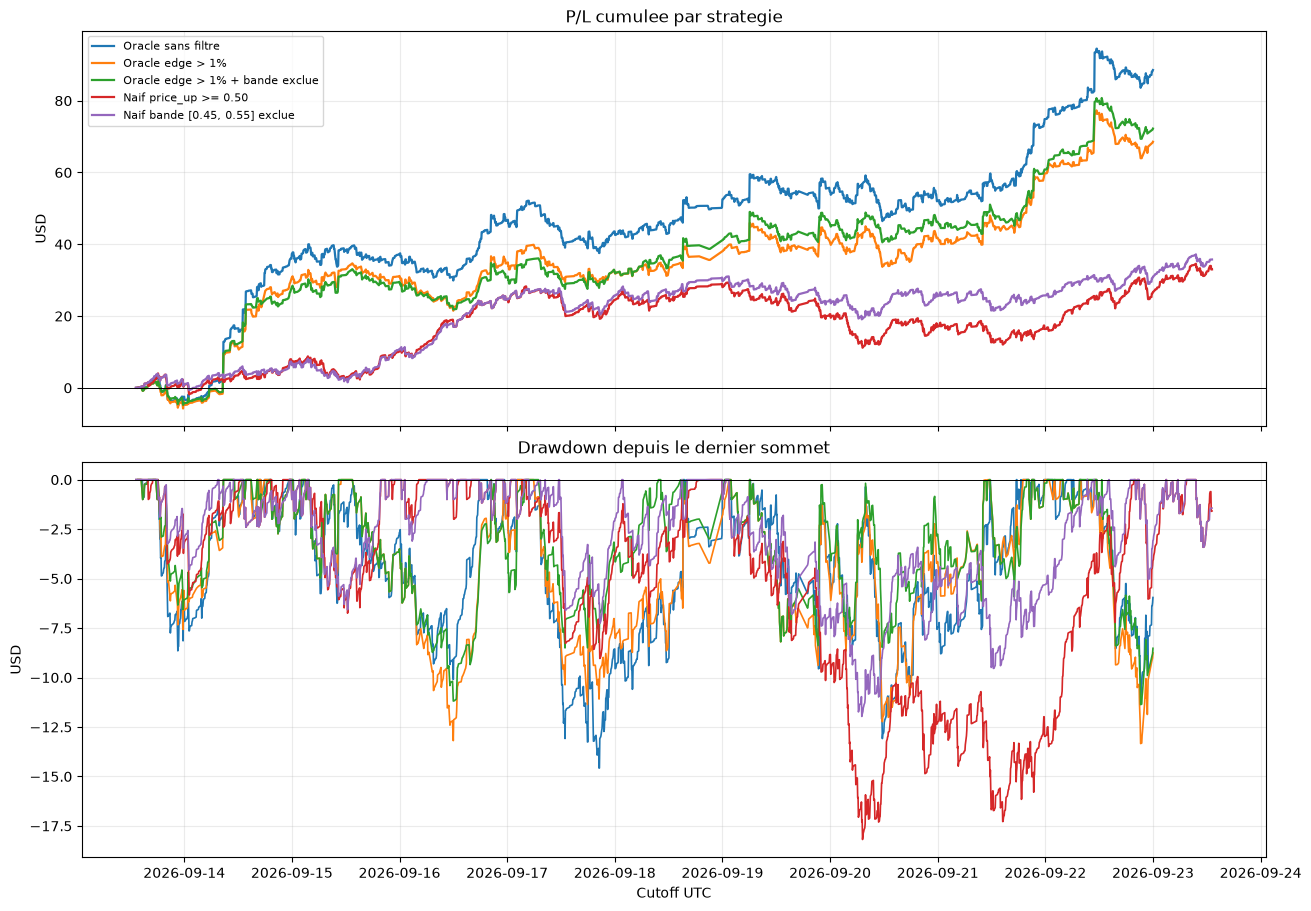

,strategy,market_id,cutoff,date_utc,side,fair_value_side,price_up,entry_vwap,entry_price_after_slippage,estimated_edge,...,won,shares,stake_usd,fee_usd,payout_usd,pnl_usd,cumulative_pnl_usd,equity_usd,running_peak_usd,drawdown_usd
0,Oracle edge > 1%,4495702,2026-09-13 13:39:00+00:00,2026-09-13,UP,0.999000,0.988721,0.988721,0.988721,0.010279,...,True,1.011408,1.0,0.0,1.011408,0.011408,0.011408,0.011408,0.011408,0.000000
1,Oracle edge > 1%,4496155,2026-09-13 14:04:00+00:00,2026-09-13,UP,0.984909,0.916722,0.916722,0.916722,0.068187,...,True,1.090843,1.0,0.0,1.090843,0.090843,0.102251,0.102251,0.102251,0.000000
2,Oracle edge > 1%,4496488,2026-09-13 14:24:00+00:00,2026-09-13,UP,0.968295,0.939694,0.939694,0.939694,0.028601,...,True,1.064176,1.0,0.0,1.064176,0.064176,0.166427,0.166427,0.166427,0.000000
3,Oracle edge > 1%,4497577,2026-09-13 14:44:00+00:00,2026-09-13,UP,0.582683,0.049920,0.049920,0.049920,0.532763,...,False,20.032014,1.0,0.0,0.000000,-1.000000,-0.833573,-0.833573,0.166427,-1.000000
4,Oracle edge > 1%,4497580,2026-09-13 14:49:00+00:00,2026-09-13,UP,0.999000,0.955983,0.955983,0.955983,0.043017,...,True,1.046044,1.0,0.0,1.046044,0.046044,-0.787530,-0.787530,0.166427,-0.953956
5,Oracle edge > 1%,4497599,2026-09-13 14:54:00+00:00,2026-09-13,DOWN,0.998246,0.044490,0.942960,0.942960,0.055286,...,True,1.060490,1.0,0.0,1.060490,0.060490,-0.727040,-0.727040,0.166427,-0.893466
6,Oracle edge > 1%,4497663,2026-09-13 15:09:00+00:00,2026-09-13,UP,0.982203,0.604593,0.604593,0.604593,0.377609,...,True,1.654005,1.0,0.0,1.654005,0.654005,-0.073035,-0.073035,0.166427,-0.239461
7,Oracle edge > 1%,4498052,2026-09-13 15:39:00+00:00,2026-09-13,DOWN,0.999000,0.024211,0.986656,0.986656,0.012344,...,True,1.013524,1.0,0.0,1.013524,0.013524,-0.059511,-0.059511,0.166427,-0.225937
8,Oracle edge > 1%,4498736,2026-09-13 15:59:00+00:00,2026-09-13,DOWN,0.834617,0.515543,0.540309,0.540309,0.294307,...,True,1.850792,1.0,0.0,1.850792,0.850792,0.791281,0.791281,0.791281,0.000000
9,Oracle edge > 1%,4499372,2026-09-13 16:29:00+00:00,2026-09-13,DOWN,0.999000,0.117480,0.918822,0.918822,0.080178,...,True,1.088350,1.0,0.0,1.088350,0.088350,0.879631,0.879631,0.879631,0.000000


In [15]:
daily_frames = []
for strategy_name, detail in trade_details.items():
    if detail.empty:
        continue
    daily = (
        detail.groupby("date_utc", as_index=False)
        .agg(paris=("market_id", "size"), gains=("won", "sum"), pnl_usd=("pnl_usd", "sum"))
    )
    daily["strategie"] = strategy_name
    daily_frames.append(daily)
daily_pnl = pd.concat(daily_frames, ignore_index=True) if daily_frames else pd.DataFrame()
if not daily_pnl.empty:
    daily_pivot = daily_pnl.pivot(index="date_utc", columns="strategie", values="pnl_usd").fillna(0)
    display(daily_pivot.style.format("${:+,.2f}"))
else:
    print("Aucun pari eligible : pas de tableau journalier.")

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True, constrained_layout=True)
for strategy_name, detail in trade_details.items():
    if detail.empty:
        continue
    axes[0].plot(detail["cutoff"], detail["cumulative_pnl_usd"], label=strategy_name, linewidth=1.6)
    axes[1].plot(detail["cutoff"], detail["drawdown_usd"], label=strategy_name, linewidth=1.2)
axes[0].set_title("P/L cumulee par strategie")
axes[0].set_ylabel("USD")
axes[0].axhline(0, color="black", linewidth=0.7)
axes[0].legend(loc="best", fontsize=8)
axes[0].grid(alpha=0.25)
axes[1].set_title("Drawdown depuis le dernier sommet")
axes[1].set_ylabel("USD")
axes[1].set_xlabel("Cutoff UTC")
axes[1].axhline(0, color="black", linewidth=0.7)
axes[1].grid(alpha=0.25)
plt.show()

# Exemples de transactions pour inspection
selected_strategy = "Oracle edge > 1%"
if selected_strategy in trade_details:
    display(trade_details[selected_strategy].head(10))

## Sensibilite au seuil d'edge

La comparaison des seuils aide a voir le compromis entre nombre de paris et ROI. Choisir le seuil sur toute la meme periode que celle evaluee introduit un biais de selection; une validation hors echantillon est necessaire avant toute conclusion predictive.

,strategie,paris,taux_reussite,pnl_net_usd,ROI_sur_mises,drawdown_max_usd
0,Oracle edge > 0.0%,1813,85.93%,$+76.26,4.21%,$-12.94
1,Oracle edge > 0.5%,1722,85.31%,$+76.17,4.42%,$-13.06
2,Oracle edge > 1.0%,1090,77.06%,$+68.55,6.29%,$-13.34
3,Oracle edge > 2.0%,906,72.63%,$+63.51,7.01%,$-14.10
4,Oracle edge > 5.0%,689,65.75%,$+59.07,8.57%,$-14.54


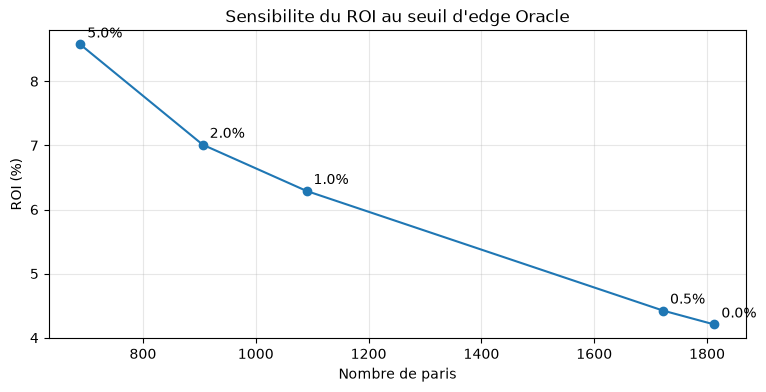

In [16]:
edge_sweep = []
for threshold in (0.0, 0.005, 0.01, 0.02, 0.05):
    result, _ = simulate_strategy(
        f"Oracle edge > {threshold:.1%}", "oracle", min_edge=threshold
    )
    edge_sweep.append(result)
edge_sweep_df = pd.DataFrame(edge_sweep)
display(edge_sweep_df[["strategie", "paris", "taux_reussite", "pnl_net_usd", "ROI_sur_mises", "drawdown_max_usd"]].style.format({
    "taux_reussite": "{:.2%}", "pnl_net_usd": "${:+,.2f}",
    "ROI_sur_mises": "{:.2%}", "drawdown_max_usd": "${:,.2f}",
}))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(edge_sweep_df["paris"], edge_sweep_df["ROI_sur_mises"] * 100, marker="o")
for row in edge_sweep_df.itertuples(index=False):
    ax.annotate(row.strategie.rsplit("> ", 1)[-1], (row.paris, row.ROI_sur_mises * 100), xytext=(5, 5), textcoords="offset points")
ax.set_title("Sensibilite du ROI au seuil d'edge Oracle")
ax.set_xlabel("Nombre de paris")
ax.set_ylabel("ROI (%)")
ax.grid(alpha=0.3)
plt.show()

## Pourquoi "Oracle sans filtre" et "Naif bande exclue" ont un P/L si different malgre des taux de reussite proches

**Le taux de reussite seul ne dit pas si une strategie gagne de l'argent.** Sur un pari binaire achete au prix `q` (entre 0 et 1) avec une probabilite reelle de gain `p` :

- si le pari gagne, le gain vaut `1/q - 1` par dollar mise; s'il perd, la perte vaut `-1` ;
- le gain moyen par dollar est donc `p/q - 1`, qui n'est positif que si **`p > q`** ;
- le seuil de rentabilite n'est pas 50 % mais **le prix d'entree lui-meme**. Acheter a 0,97 exige de gagner plus de 97 % du temps.

La question n'est donc pas « combien de paris gagnent ? » mais « **gagnent-ils plus souvent que le prix paye ne le laissait prevoir ?** ». Un ecart de quelques points de probabilite, rapporte au prix, fait toute la difference de ROI.

**Les deux strategies ne choisissent pas les memes paris :**

- **La strategie naive achete toujours le favori du marche** (`price_up >= 0.5` : UP, sinon DOWN). Elle paie donc presque toujours un prix eleve, proche de la probabilite que le marche attribue deja a l'issue. Son taux de reussite est haut, mais a peine superieur au prix paye : la marge est mince.
- **L'Oracle choisit son cote avec son propre modele.** Le plus souvent il est d'accord avec le marche et achete aussi le favori. Mais quand il est en desaccord, il achete **l'outsider** a bas prix (par exemple 0,10 a 0,40). Ces paris perdent plus souvent, ce qui fait baisser le taux de reussite global, mais chaque gain rapporte plusieurs fois la mise.

La cellule suivante mesure ces effets sur les donnees :

1. **Profil global** : taux de reussite, prix d'entree moyen et marge `reussite - prix`, qui explique mieux le ROI que le taux de reussite seul.
2. **Decomposition par tranche de prix d'entree** : on y voit dans quelles tranches chaque strategie gagne ou perd de l'argent.
3. **Comparaison marche par marche** : sur les marches communs, l'ecart vient-il des paris ou les deux strategies choisissent le meme cote, ou de ceux ou elles s'opposent ?

1. Profil global


,paris,taux_reussite,prix_entree_moyen,marge_reussite_moins_prix,gain_moyen_si_gagne_usd,pnl_net_usd,ROI
Oracle sans filtre,2475.000000,88.04%,0.8598,+2.06%,$0.1765,$+88.54,+3.58%
"Naif bande [0.45, 0.55] exclue",2432.000000,91.74%,0.9042,+1.31%,$0.1061,$+35.76,+1.47%


2. Decomposition par tranche de prix d'entree


,strategie,prix_entree,paris,taux_reussite,prix_entree_moyen,marge_reussite_moins_prix,gain_moyen_si_gagne_usd,pnl_net_usd,ROI
0,Oracle sans filtre,"(-0.001, 0.3]",101,19.80%,0.1717,+2.63%,$5.0271,$+19.54,+19.35%
1,Oracle sans filtre,"(0.3, 0.5]",137,47.45%,0.4118,+6.26%,$1.4382,$+21.48,+15.68%
2,Oracle sans filtre,"(0.5, 0.7]",181,62.43%,0.6101,+1.42%,$0.6456,$+4.96,+2.74%
3,Oracle sans filtre,"(0.7, 0.9]",405,87.41%,0.8183,+5.58%,$0.2217,$+27.47,+6.78%
4,Oracle sans filtre,"(0.9, 0.97]",405,95.31%,0.9417,+1.14%,$0.0621,$+4.98,+1.23%
5,Oracle sans filtre,"(0.97, 1.0]",1246,99.60%,0.9880,+0.80%,$0.0122,$+10.10,+0.81%
6,"Naif bande [0.45, 0.55] exclue","(0.3, 0.5]",1,100.00%,0.4077,+59.23%,$1.4528,$+1.45,+145.28%
7,"Naif bande [0.45, 0.55] exclue","(0.5, 0.7]",248,60.08%,0.6251,-2.43%,$0.6056,$-8.76,-3.53%
8,"Naif bande [0.45, 0.55] exclue","(0.7, 0.9]",530,85.85%,0.8151,+4.34%,$0.2268,$+28.20,+5.32%
9,"Naif bande [0.45, 0.55] exclue","(0.9, 0.97]",452,95.13%,0.9411,+1.02%,$0.0627,$+4.97,+1.10%


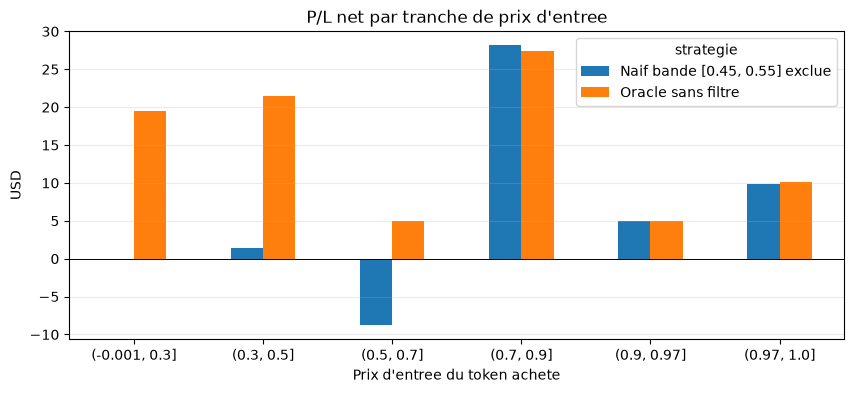

3. Comparaison marche par marche


,marches,reussite_oracle,reussite_naif,prix_moyen_oracle,prix_moyen_naif,pnl_oracle_usd,pnl_naif_usd,ecart_pnl_usd
situation,,,,,,,,
cotes opposes,202,31.19%,68.81%,0.2824,0.7329,$+29.24,$-11.81,$+41.05
meme cote,2094,93.89%,93.89%,0.9215,0.9215,$+42.75,$+42.75,$+0.00
seulement Naif,136,-,92.65%,-,0.8932,$+0.00,$+4.82,$-4.82
seulement Oracle,179,83.80%,-,0.7901,-,$+16.55,$+0.00,$+16.55


Ecart total de P/L (Oracle - Naif) : $+52.78
  - cotes opposes    :   202 marches, ecart $  +41.05 (+78% de l'ecart)
  - meme cote        :  2094 marches, ecart $   +0.00 (+0% de l'ecart)
  - seulement Naif   :   136 marches, ecart $   -4.82 (-9% de l'ecart)
  - seulement Oracle :   179 marches, ecart $  +16.55 (+31% de l'ecart)
Paris Oracle sur l'outsider (prix < 0,5) : 238 paris, reussite 35.7%, P/L $+41.02


In [17]:
ORACLE_NAME = "Oracle sans filtre"
NAIVE_NAME = "Naif bande [0.45, 0.55] exclue"
compared = {ORACLE_NAME: trade_details[ORACLE_NAME], NAIVE_NAME: trade_details[NAIVE_NAME]}


def trade_profile(trades: pd.DataFrame) -> dict:
    stake = trades["stake_usd"].sum()
    win_rate = trades["won"].mean()
    mean_entry = trades["entry_price_after_slippage"].mean()
    return {
        "paris": len(trades),
        "taux_reussite": win_rate,
        "prix_entree_moyen": mean_entry,
        "marge_reussite_moins_prix": win_rate - mean_entry,
        "gain_moyen_si_gagne_usd": trades.loc[trades["won"], "pnl_usd"].mean(),
        "pnl_net_usd": trades["pnl_usd"].sum(),
        "ROI": trades["pnl_usd"].sum() / stake if stake else math.nan,
    }


profile_format = {
    "taux_reussite": "{:.2%}", "prix_entree_moyen": "{:.4f}",
    "marge_reussite_moins_prix": "{:+.2%}", "gain_moyen_si_gagne_usd": "${:.4f}",
    "pnl_net_usd": "${:+,.2f}", "ROI": "{:+.2%}",
}

print("1. Profil global")
display(pd.DataFrame({name: trade_profile(t) for name, t in compared.items()}).T.style.format(profile_format))

print("2. Decomposition par tranche de prix d'entree")
price_bins = [0.0, 0.3, 0.5, 0.7, 0.9, 0.97, 1.0]
bucket_rows = []
for name, trades in compared.items():
    buckets = pd.cut(trades["entry_price_after_slippage"], price_bins, include_lowest=True)
    for bucket, group in trades.groupby(buckets, observed=True):
        bucket_rows.append({"strategie": name, "prix_entree": str(bucket), **trade_profile(group)})
bucket_df = pd.DataFrame(bucket_rows)
display(bucket_df.style.format(profile_format))

pnl_by_bucket = bucket_df.pivot(index="prix_entree", columns="strategie", values="pnl_net_usd").fillna(0)
pnl_by_bucket = pnl_by_bucket.reindex([str(b) for b in pd.cut([0.1], price_bins, include_lowest=True).categories])
ax = pnl_by_bucket.plot.bar(figsize=(10, 4), rot=0)
ax.axhline(0, color="black", linewidth=0.7)
ax.set_title("P/L net par tranche de prix d'entree")
ax.set_xlabel("Prix d'entree du token achete")
ax.set_ylabel("USD")
ax.grid(alpha=0.25, axis="y")
plt.show()

print("3. Comparaison marche par marche")
columns = ["market_id", "side", "entry_price_after_slippage", "won", "pnl_usd"]
pairs = compared[ORACLE_NAME][columns].merge(
    compared[NAIVE_NAME][columns], on="market_id", how="outer",
    suffixes=("_oracle", "_naif"), indicator=True, validate="one_to_one",
)
pairs["situation"] = "seulement Naif"
pairs.loc[pairs["_merge"] == "left_only", "situation"] = "seulement Oracle"
both = pairs["_merge"] == "both"
pairs.loc[both & (pairs["side_oracle"] == pairs["side_naif"]), "situation"] = "meme cote"
pairs.loc[both & (pairs["side_oracle"] != pairs["side_naif"]), "situation"] = "cotes opposes"
situation_df = pairs.groupby("situation").agg(
    marches=("market_id", "size"),
    reussite_oracle=("won_oracle", "mean"),
    reussite_naif=("won_naif", "mean"),
    prix_moyen_oracle=("entry_price_after_slippage_oracle", "mean"),
    prix_moyen_naif=("entry_price_after_slippage_naif", "mean"),
    pnl_oracle_usd=("pnl_usd_oracle", "sum"),
    pnl_naif_usd=("pnl_usd_naif", "sum"),
)
situation_df["ecart_pnl_usd"] = situation_df["pnl_oracle_usd"] - situation_df["pnl_naif_usd"]
display(situation_df.style.format({
    "reussite_oracle": "{:.2%}", "reussite_naif": "{:.2%}",
    "prix_moyen_oracle": "{:.4f}", "prix_moyen_naif": "{:.4f}",
    "pnl_oracle_usd": "${:+,.2f}", "pnl_naif_usd": "${:+,.2f}", "ecart_pnl_usd": "${:+,.2f}",
}, na_rep="-"))

total_gap = compared[ORACLE_NAME]["pnl_usd"].sum() - compared[NAIVE_NAME]["pnl_usd"].sum()
underdogs = compared[ORACLE_NAME].loc[compared[ORACLE_NAME]["entry_price_after_slippage"] < 0.5]
print(f"Ecart total de P/L (Oracle - Naif) : ${total_gap:+,.2f}")
for situation, row in situation_df.iterrows():
    share = row["ecart_pnl_usd"] / total_gap if total_gap else math.nan
    print(f"  - {situation:17s}: {row['marches']:5d} marches, ecart ${row['ecart_pnl_usd']:+8.2f} ({share:+.0%} de l'ecart)")
print(
    f"Paris Oracle sur l'outsider (prix < 0,5) : {len(underdogs)} paris, "
    f"reussite {underdogs['won'].mean():.1%}, P/L ${underdogs['pnl_usd'].sum():+,.2f}"
)

### Lecture des resultats (donnees du 13 au 23 septembre 2026, bornes Oracle 0,001 / 0,999)

**1. Le taux de reussite trompe : c'est la marge au-dessus du prix qui compte.** La strategie naive gagne plus souvent (91,7 % contre 88,0 %), mais elle paie aussi plus cher (0,904 contre 0,860 en moyenne). Sa marge `reussite - prix` n'est que de +1,3 point, contre +2,1 points pour l'Oracle. Comme un gain sur un favori rapporte peu (environ 0,11 $ par dollar pour le naif), il suffit de peu de pertes a -1 $ pour effacer beaucoup de gains.

**2. Sur les favoris, les deux strategies sont identiques.** Sur les 2 094 marches ou elles choisissent le meme cote, elles achetent le meme token au meme prix et obtiennent exactement le meme P/L (+42,75 $). **Cette zone n'explique aucune partie de l'ecart.**

**3. Tout se joue quand l'Oracle contredit le marche.** Sur 202 marches, l'Oracle achete l'outsider (prix moyen 0,28) pendant que le naif achete le favori (prix moyen 0,73) :

- l'Oracle ne gagne que 31 % de ces paris, mais chaque gain rapporte environ 2,5 fois la mise, d'ou **+29,24 $** ;
- le naif en gagne 69 %, mais c'est moins que les 73 % implicites dans le prix paye, d'ou **-11,81 $** ;
- ces 202 marches, soit 8 % des paris, expliquent **+41 $ sur les 53 $ d'ecart (78 %)**.

C'est aussi pour cela que l'Oracle a un taux de reussite global plus bas : ses paris contrariants perdent souvent, mais ils sont rentables.

**4. Le reste vient de la couverture.** L'Oracle joue 179 marches que le naif ignore (VWAP UP absente ou `price_up` dans la bande d'incertitude) et y gagne +16,55 $. A l'inverse, le naif joue 136 marches ignorees par l'Oracle (Oracle non score ou VWAP absente sur son cote) pour +4,82 $.

**5. La tranche 0,5-0,7 est la faiblesse du naif.** Quand le favori est cote entre 0,5 et 0,7, le naif gagne 60 % des paris pour un prix moyen de 0,63 : il perd -8,76 $. Dans la meme tranche, l'Oracle reste positif (+4,96 $), parce qu'il y achete le favori seulement quand son modele le soutient.

**En resume :** l'avantage de l'Oracle ne vient pas de sa capacite a trouver plus souvent le bon cote, mais du fait qu'il repere des cas ou le marche **sous-evalue l'outsider**. Il y achete des tokens bon marche qui gagnent plus souvent que leur prix ne l'indique. Cet avantage repose sur seulement 238 paris outsider (+41 $) : la prudence s'impose, car quelques gains importants suffisent a faire basculer le resultat, et les prix d'entree sont des VWAP historiques, pas des prix garantis.

## Variante : edge minimal different pour favoris et outsiders, mise reduite sur les outsiders

On repart des paris de la strategie "Oracle sans filtre" (meme cote, meme prix d'entree) et on les separe en deux categories selon le prix du token achete :

- **favori** : prix d'entree >= 0,5. Le pari rapporte peu, donc l'edge doit au moins couvrir le cout d'execution : seuil `FAVORITE_MIN_EDGE` ;
- **outsider** : prix d'entree < 0,5. L'Oracle contredit le marche; une erreur de modele coute plus cher et le cout d'execution relatif est plus eleve. On exige un edge plus grand, `UNDERDOG_MIN_EDGE`, et on ne mise qu'une fraction `UNDERDOG_STAKE_FRACTION` de la mise standard.

La bande d'incertitude sur la fair value reste appliquee si `SPLIT_EXCLUDE_BAND = True`. Avec des mises variables, le ROI se calcule sur le total mise.

Indicateurs ajoutes pour juger la robustesse :

- **P/L sans les 10 meilleurs paris** : si ce chiffre devient negatif, le resultat depend de quelques coups chanceux ;
- **P/L / drawdown max** : gain obtenu par dollar de perte maximale subie, pour comparer des strategies qui prennent des risques differents ;
- **jours positifs** : regularite du resultat au jour le jour.

,strategie,paris,paris_outsider,mise_usd,pnl_net_usd,ROI,drawdown_max_usd,pnl_sur_drawdown,pnl_sans_top10_usd,jours_positifs
0,Oracle sans filtre,2475,238,"$2,475.00",$+88.54,+3.58%,$-14.58,6.07,$+20.56,7/10
1,Oracle edge > 1% + bande exclue,1050,200,"$1,050.00",$+72.22,+6.88%,$-11.37,6.35,$+4.25,9/10
2,"Naif bande [0.45, 0.55] exclue",2432,1,"$2,432.00",$+35.76,+1.47%,$-11.97,2.99,$+26.46,10/11
3,"Oracle split (fav > 1%, out > 5%, mise out x0.5)",1050,200,$950.00,$+49.95,+5.26%,$-9.32,5.36,$+15.96,9/10


Detail de la variante par categorie


,strategie,paris,paris_outsider,mise_usd,pnl_net_usd,ROI,drawdown_max_usd,pnl_sur_drawdown,pnl_sans_top10_usd,jours_positifs
0,favori,850,0,$850.00,$+27.67,+3.26%,$-10.94,2.53,$+18.37,8/10
1,outsider,200,200,$100.00,$+22.28,+22.28%,$-7.99,2.79,$-11.71,6/10


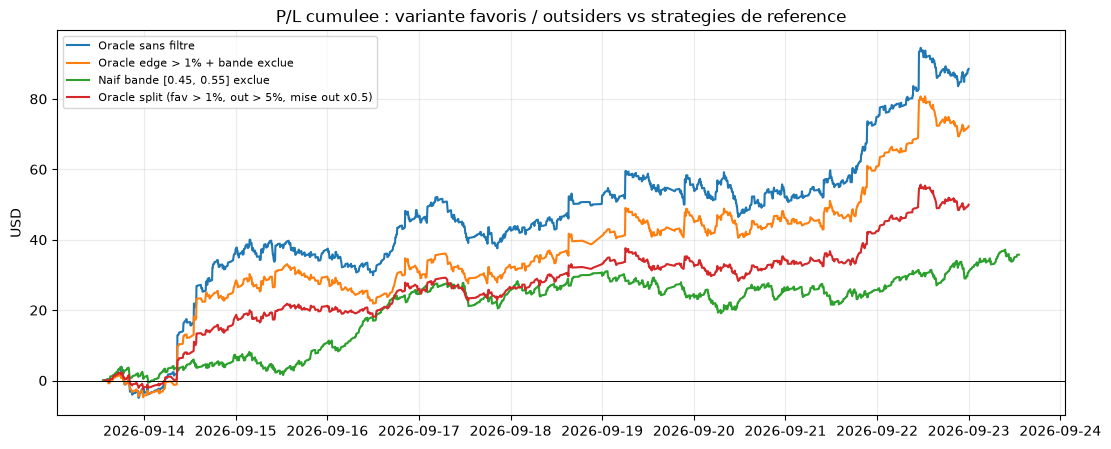

In [18]:
FAVORITE_MIN_EDGE = 0.01
UNDERDOG_MIN_EDGE = 0.05
UNDERDOG_STAKE_FRACTION = 0.5
SPLIT_EXCLUDE_BAND = True

base_trades = trade_details["Oracle sans filtre"]


def split_strategy(
    trades: pd.DataFrame,
    favorite_edge: float,
    underdog_edge: float,
    underdog_fraction: float,
    exclude_band: bool = True,
) -> pd.DataFrame:
    is_underdog = trades["entry_vwap"] < 0.5
    threshold = is_underdog.map({True: underdog_edge, False: favorite_edge})
    keep = trades["estimated_edge"] > threshold
    if exclude_band:
        keep &= ~trades["fair_value_side"].between(*UNCERTAINTY_BAND)
    t = trades[keep].copy()
    t["categorie"] = (t["entry_vwap"] < 0.5).map({True: "outsider", False: "favori"})
    t["stake_usd"] = STAKE_USD * t["categorie"].map({"outsider": underdog_fraction, "favori": 1.0})
    t["fee_usd"] = t["stake_usd"] * FEE_RATE
    t["payout_usd"] = t["won"] * t["stake_usd"] / t["entry_price_after_slippage"]
    t["pnl_usd"] = t["payout_usd"] - t["stake_usd"] - t["fee_usd"]
    return t.sort_values(["cutoff", "market_id"]).reset_index(drop=True)


def robust_metrics(name: str, trades: pd.DataFrame) -> dict:
    if trades.empty:
        return {"strategie": name, "paris": 0}
    cumulative = trades["pnl_usd"].cumsum()
    drawdown = float((cumulative - cumulative.cummax().clip(lower=0)).min())
    pnl = float(trades["pnl_usd"].sum())
    stake = float(trades["stake_usd"].sum())
    daily = trades.groupby("date_utc")["pnl_usd"].sum()
    return {
        "strategie": name,
        "paris": len(trades),
        "paris_outsider": int((trades["entry_vwap"] < 0.5).sum()),
        "mise_usd": stake,
        "pnl_net_usd": pnl,
        "ROI": pnl / stake if stake else math.nan,
        "drawdown_max_usd": drawdown,
        "pnl_sur_drawdown": pnl / -drawdown if drawdown < 0 else math.nan,
        "pnl_sans_top10_usd": pnl - float(trades["pnl_usd"].nlargest(10).sum()),
        "jours_positifs": f"{int((daily > 0).sum())}/{len(daily)}",
    }


robust_format = {
    "mise_usd": "${:,.2f}", "pnl_net_usd": "${:+,.2f}", "ROI": "{:+.2%}",
    "drawdown_max_usd": "${:,.2f}", "pnl_sur_drawdown": "{:.2f}", "pnl_sans_top10_usd": "${:+,.2f}",
}

split_name = (
    f"Oracle split (fav > {FAVORITE_MIN_EDGE:.0%}, out > {UNDERDOG_MIN_EDGE:.0%}, "
    f"mise out x{UNDERDOG_STAKE_FRACTION:g})"
)
split_trades = split_strategy(
    base_trades, FAVORITE_MIN_EDGE, UNDERDOG_MIN_EDGE, UNDERDOG_STAKE_FRACTION, SPLIT_EXCLUDE_BAND
)
comparison = {
    "Oracle sans filtre": base_trades,
    f"Oracle edge > {MIN_EDGE:.0%} + bande exclue": trade_details[f"Oracle edge > {MIN_EDGE:.0%} + bande exclue"],
    "Naif bande [0.45, 0.55] exclue": trade_details["Naif bande [0.45, 0.55] exclue"],
    split_name: split_trades,
}
display(pd.DataFrame([robust_metrics(n, t) for n, t in comparison.items()]).style.format(robust_format))

print("Detail de la variante par categorie")
display(pd.DataFrame(
    [robust_metrics(cat, group) for cat, group in split_trades.groupby("categorie")]
).style.format(robust_format))

fig, ax = plt.subplots(figsize=(13, 5))
for name, trades in comparison.items():
    ax.plot(trades["cutoff"], trades["pnl_usd"].cumsum(), label=name, linewidth=1.5)
ax.axhline(0, color="black", linewidth=0.7)
ax.set_title("P/L cumulee : variante favoris / outsiders vs strategies de reference")
ax.set_ylabel("USD")
ax.legend(fontsize=8)
ax.grid(alpha=0.25)
plt.show()

### Grille de parametres et validation hors echantillon

**Choisir les seuils sur la periode qui sert aussi a les evaluer surestime les resultats.** On coupe donc la periode en deux :

- **apprentissage** : premiere moitie des jours, qui sert a choisir la meilleure combinaison ;
- **test** : seconde moitie, jamais utilisee pour le choix, qui mesure la performance de cette combinaison.

Le critere de choix est le ratio **P/L / drawdown max** sur la periode d'apprentissage, pour privilegier un gain regulier plutot qu'un gain obtenu au prix de fortes pertes intermediaires. On compare ensuite, sur la periode de test seule, la combinaison retenue aux strategies de reference.

A noter : avec la bande exclue, un pari outsider a toujours un edge d'au moins 5 points, car l'Oracle lui donne au moins 0,55 et le marche moins de 0,5. Un seuil outsider de 5 % ou moins ne retire donc aucun pari; la grille teste des seuils plus eleves.

Avec seulement 5 jours d'apprentissage et 5 jours de test, ce controle reste indicatif : il permet de detecter un surajustement flagrant, pas de valider definitivement une strategie.

In [19]:
FAVORITE_EDGE_GRID = (0.0, 0.01, 0.02, 0.03)
UNDERDOG_EDGE_GRID = (0.05, 0.10, 0.20, 0.30)
UNDERDOG_FRACTION_GRID = (1.0, 0.5, 0.25)

trade_days = sorted(base_trades["date_utc"].unique())
split_day = trade_days[len(trade_days) // 2]
train_trades = base_trades[base_trades["date_utc"] < split_day]
test_trades = base_trades[base_trades["date_utc"] >= split_day]
print(f"Apprentissage : {trade_days[0]} -> veille du {split_day} | Test : {split_day} -> {trade_days[-1]}")

grid_rows = []
for fav_edge in FAVORITE_EDGE_GRID:
    for dog_edge in UNDERDOG_EDGE_GRID:
        for fraction in UNDERDOG_FRACTION_GRID:
            params = (fav_edge, dog_edge, fraction, SPLIT_EXCLUDE_BAND)
            train_m = robust_metrics("train", split_strategy(train_trades, *params))
            test_m = robust_metrics("test", split_strategy(test_trades, *params))
            grid_rows.append({
                "edge_favori": fav_edge,
                "edge_outsider": dog_edge,
                "mise_outsider": fraction,
                "paris_train": train_m.get("paris", 0),
                "pnl_train_usd": train_m.get("pnl_net_usd", math.nan),
                "ratio_train": train_m.get("pnl_sur_drawdown", math.nan),
                "paris_test": test_m.get("paris", 0),
                "pnl_test_usd": test_m.get("pnl_net_usd", math.nan),
                "ROI_test": test_m.get("ROI", math.nan),
                "drawdown_test_usd": test_m.get("drawdown_max_usd", math.nan),
            })
grid_df = pd.DataFrame(grid_rows).sort_values("ratio_train", ascending=False, na_position="last")
grid_format = {
    "edge_favori": "{:.0%}", "edge_outsider": "{:.0%}", "mise_outsider": "x{:g}",
    "pnl_train_usd": "${:+,.2f}", "ratio_train": "{:.2f}", "pnl_test_usd": "${:+,.2f}",
    "ROI_test": "{:+.2%}", "drawdown_test_usd": "${:,.2f}",
}
print("10 meilleures combinaisons selon le ratio P/L / drawdown en apprentissage")
display(grid_df.head(10).style.format(grid_format))

best = grid_df.iloc[0]
best_params = (best["edge_favori"], best["edge_outsider"], best["mise_outsider"], SPLIT_EXCLUDE_BAND)
naive_trades = trade_details["Naif bande [0.45, 0.55] exclue"]
test_comparison = {
    "Oracle sans filtre": test_trades,
    "Oracle edge > 1% + bande exclue": split_strategy(test_trades, 0.01, 0.01, 1.0, True),
    "Naif bande [0.45, 0.55] exclue": naive_trades[naive_trades["date_utc"].between(split_day, trade_days[-1])],
    (
        f"Split retenu (fav > {best['edge_favori']:.0%}, out > {best['edge_outsider']:.0%}, "
        f"mise out x{best['mise_outsider']:g})"
    ): split_strategy(test_trades, *best_params),
}
print(f"Comparaison sur la periode de test uniquement ({split_day} -> {trade_days[-1]})")
display(pd.DataFrame([robust_metrics(n, t) for n, t in test_comparison.items()]).style.format(robust_format))

rank_test = grid_df["pnl_test_usd"].rank(ascending=False, method="min")
print(
    f"La combinaison retenue en apprentissage est classee {int(rank_test.iloc[0])}e "
    f"sur {len(grid_df)} en P/L de test."
)

Apprentissage : 2026-09-13 -> veille du 2026-09-18 | Test : 2026-09-18 -> 2026-09-22
10 meilleures combinaisons selon le ratio P/L / drawdown en apprentissage


,edge_favori,edge_outsider,mise_outsider,paris_train,pnl_train_usd,ratio_train,paris_test,pnl_test_usd,ROI_test,drawdown_test_usd
14,1%,5%,x0.25,515,$+23.47,4.13,535,$+15.34,+3.38%,$-9.74
17,1%,10%,x0.25,515,$+23.47,4.13,535,$+15.34,+3.38%,$-9.74
20,1%,20%,x0.25,500,$+23.27,4.10,526,$+15.44,+3.42%,$-9.56
13,1%,5%,x0.5,515,$+26.62,4.02,535,$+23.33,+4.85%,$-9.32
16,1%,10%,x0.5,515,$+26.62,4.02,535,$+23.33,+4.85%,$-9.32
19,1%,20%,x0.5,500,$+26.23,3.96,526,$+23.53,+4.94%,$-8.96
8,0%,20%,x0.25,858,$+26.31,3.87,889,$+18.33,+2.25%,$-8.71
7,0%,20%,x0.5,858,$+29.27,3.85,889,$+26.41,+3.15%,$-8.11
2,0%,5%,x0.25,873,$+26.51,3.81,898,$+18.22,+2.23%,$-8.89
5,0%,10%,x0.25,873,$+26.51,3.81,898,$+18.22,+2.23%,$-8.89


Comparaison sur la periode de test uniquement (2026-09-18 -> 2026-09-22)


,strategie,paris,paris_outsider,mise_usd,pnl_net_usd,ROI,drawdown_max_usd,pnl_sur_drawdown,pnl_sans_top10_usd,jours_positifs
0,Oracle sans filtre,1266,129,"$1,266.00",$+44.95,+3.55%,$-13.09,3.44,$-9.45,4/5
1,Oracle edge > 1% + bande exclue,535,108,$535.00,$+39.30,+7.35%,$-11.37,3.46,$-13.47,5/5
2,"Naif bande [0.45, 0.55] exclue",1170,1,"$1,170.00",$+5.28,+0.45%,$-11.97,0.44,$-3.82,4/5
3,"Split retenu (fav > 1%, out > 5%, mise out x0.25)",535,108,$454.00,$+15.34,+3.38%,$-9.74,1.58,$+1.09,4/5


La combinaison retenue en apprentissage est classee 38e sur 48 en P/L de test.


### Lecture (apprentissage 13-17 septembre, test 18-22 septembre 2026)

- **Le seuil d'edge outsider change peu les resultats.** Entre 5 % et 10 %, les paris sont identiques; a 20 %, seuls quelques-uns disparaissent. Les outsiders retenus ont presque tous un edge estime tres eleve.
- **Reduire la mise outsider baisse le P/L sans ameliorer nettement le risque.** La combinaison choisie en apprentissage (mise outsider x0,25) ne fait que +15,34 $ en test, contre +39,30 $ pour "edge > 1 % + bande exclue" a mise pleine, avec un drawdown a peine plus faible (-9,74 $ contre -11,37 $). Elle est classee 38e sur 48 en test.
- **Le choix en apprentissage est quasi aleatoire.** Les meilleurs ratios y sont tres proches (4,13 contre 4,02) : sur 5 jours, l'ecart entre combinaisons est plus petit que le bruit.
- **En test, les strategies Oracle restent nettement meilleures que la strategie naive** (+39 $ a +45 $ contre +5 $), ce qui confirme hors echantillon l'interet du signal Oracle.
- **Mais leur gain reste concentre** : sans leurs 10 meilleurs paris, les strategies Oracle a mise pleine deviennent negatives en test.

**Conclusion provisoire :** reduire la mise sur les outsiders est un choix de gestion du risque, pas une amelioration de performance. Sur ces donnees, la mise pleine avec "edge > 1 % + bande exclue" reste le meilleur compromis. Ces conclusions restent a confirmer sur une periode plus longue.

## Export facultatif et limites

Aucune sortie n'est ecrite par defaut. Pour exporter, renseigner `OUTPUT_DIR` dans la cellule ci-dessous; les fichiers sont places dans un dossier distinct et les sources ne sont jamais remplacees.

Les prix sont des VWAP ponderees par la taille des executions dans les 15 secondes se terminant a T-120. Elles ne representent ni un bid/ask garanti ni une profondeur disponible. Les resultats supposent le reglement binaire selon `outcome_polymarket`; les frais et le slippage valent les parametres configurables. Les exclusions sans prediction ou prix exploitable reduisent la couverture. Les resultats sur cette periode ne garantissent pas les performances futures; utiliser une validation temporelle hors echantillon.

In [20]:
# Laisser a None pour ne rien ecrire. Exemple: PROJECT_ROOT / "data/backtesting/results_notebook"
OUTPUT_DIR = None

if OUTPUT_DIR is None:
    print("Export desactive; les donnees source n'ont pas ete modifiees.")
else:
    output_dir = Path(OUTPUT_DIR).expanduser().resolve()
    output_dir.mkdir(parents=True, exist_ok=True)
    if output_dir in {BACKTEST_PATH.parent.resolve(), PRICE_PATH.parent.resolve()}:
        raise ValueError("Choisir un dossier de sortie distinct des dossiers sources.")

    summary_export = summary_df.drop(columns="exclusions", errors="ignore")
    summary_export.to_csv(output_dir / "strategy_summary.csv", index=False)
    daily_pnl.to_csv(output_dir / "daily_pnl.csv", index=False)
    nonempty_trades = [frame for frame in trade_details.values() if not frame.empty]
    if nonempty_trades:
        pd.concat(nonempty_trades, ignore_index=True).to_csv(
            output_dir / "strategy_trades.csv", index=False
        )
    exclusion_report = {
        item["strategie"]: item.get("exclusions", {}) for item in summaries
    }
    (output_dir / "exclusions.json").write_text(
        json.dumps(exclusion_report, indent=2, ensure_ascii=False), encoding="utf-8"
    )
    print(f"Resultats exportes dans: {output_dir}")

Export desactive; les donnees source n'ont pas ete modifiees.
